In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sortedcontainers import SortedDict
import matplotlib.pyplot as plt

In [26]:
selected_options = [f.stem for f in Path('/Users/suryasridhar/GitHubProject/ncsu_finmath_summer_2026/OptionsData').rglob('*.data')]

In [27]:
import time

import requests
import pandas as pd

def get_btc_spot_15min(start_ts, end_ts):
    url      = "https://www.okx.com/api/v5/market/history-candles"
    all_data = []
    after    = end_ts
    
    while True:
        params = {
            "instId": "BTC-USDT",
            "bar"   : "15m",
            "after" : str(after),
            "limit" : "100"
        }
        resp = requests.get(url, params=params).json()
        data = resp.get('data', [])
        
        if not data:
            break
        
        all_data.extend(data)
        oldest = int(data[-1][0])
        
        if oldest <= start_ts:
            break
        
        after = oldest
        time.sleep(0.1)
    
    df = pd.DataFrame(all_data, columns=[
        'ts','open','high','low','close','vol','volCcy','volCcyQuote','confirm'
    ])
    df['ts']    = pd.to_datetime(df['ts'].astype(int), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[df['ts'] >= pd.Timestamp(start_ts, unit='ms')]
    df = df.sort_values('ts').reset_index(drop=True)
    
    return df[['ts', 'close']].rename(columns={'close': 'btc_spot'})

start = int(pd.Timestamp('2026-05-01').timestamp() * 1000)
end   = int(pd.Timestamp('2026-05-16').timestamp() * 1000)

btc_spot = get_btc_spot_15min(start, end)
print(f"Got {len(btc_spot)} rows")
print(btc_spot.head())

Got 1440 rows
                   ts  btc_spot
0 2026-05-01 00:00:00   76476.2
1 2026-05-01 00:15:00   76529.2
2 2026-05-01 00:30:00   76538.0
3 2026-05-01 00:45:00   76463.1
4 2026-05-01 01:00:00   76566.4


In [13]:
btc_spot.tail()

,ts,btc_spot
1435,2026-05-15 22:45:00,79118.2
1436,2026-05-15 23:00:00,79110.6
1437,2026-05-15 23:15:00,79118.7
1438,2026-05-15 23:30:00,79142.3
1439,2026-05-15 23:45:00,79116.6


In [29]:
contract_name = 'BTC-USD-260626-80000-C'

In [30]:
TRADES_PATH = '/Users/suryasridhar/GitHubProject/ncsu_finmath_summer_2026/OptionsData/BTC-USD-optionchain-trades-2026-05.csv'

trades_all = pd.read_csv(TRADES_PATH)
trades_all['datetime'] = pd.to_datetime(trades_all['created_time'], unit='ms')

trades_contract = trades_all[
    trades_all['instrument_name'] == contract_name
].copy()

print(f"Trades for {contract_name}: {len(trades_contract)}")
print(trades_contract[['datetime', 'side', 'price', 'size']].head(5))

Trades for BTC-USD-260626-80000-C: 469
                      datetime  side  price   size
245334 2026-05-01 03:21:52.177  sell  0.045  100.0
245335 2026-05-01 12:08:41.069   buy  0.045    1.0
245336 2026-05-01 12:09:07.394   buy  0.045    1.0
245337 2026-05-01 13:05:30.504   buy  0.050    2.0
245338 2026-05-01 13:05:30.504   buy  0.050   29.0


In [31]:
contract_name = 'BTC-USD-260626-80000-C'

In [32]:
import pandas as pd

orderbook_raw = pd.read_parquet('../../RandomData/orderbook_cache.parquet')

contract_ob = orderbook_raw[
    (orderbook_raw['expiry'] == '260626') &
    (orderbook_raw['strike'] == 80000.0) &
    (orderbook_raw['option_type'] == 'C')
].copy()

print(f"Contract rows: {len(contract_ob)}")
print(contract_ob[['datetime', 'mid_btc', 'best_bid_btc', 'best_ask_btc']].head(5))

Contract rows: 1440
                   datetime  mid_btc  best_bid_btc  best_ask_btc
82  2026-05-01 00:00:00.006  0.03975        0.0395        0.0400
287 2026-05-01 00:15:00.006  0.04025        0.0400        0.0405
491 2026-05-01 00:30:00.006  0.04025        0.0400        0.0405
698 2026-05-01 00:45:00.006  0.04025        0.0400        0.0405
904 2026-05-01 01:00:00.006  0.04025        0.0400        0.0405


In [33]:
TRAIN_END = '2026-05-11'

contract_mid_snap_train = contract_ob[
    contract_ob['datetime'] < pd.Timestamp(TRAIN_END)
].copy()

contract_mid_snap_test = contract_ob[
    contract_ob['datetime'] >= pd.Timestamp(TRAIN_END)
].copy()

print(f"Train: {len(contract_mid_snap_train)} rows")
print(f"Test:  {len(contract_mid_snap_test)} rows")

Train: 960 rows
Test:  480 rows


In [34]:
contract_mid_snap = contract_ob.rename(columns={
    'best_bid_btc': 'best_bid',
    'best_ask_btc': 'best_ask',
    'mid_btc':      'mid'
}).copy()

# merge spot price using datetime column
contract_mid_snap = pd.merge_asof(
    contract_mid_snap.sort_values('datetime'),
    btc_spot.rename(columns={'ts': 'datetime'}).sort_values('datetime'),
    on='datetime',
    direction='backward'
)

contract_mid_snap['mid_usd'] = contract_mid_snap['mid'] * contract_mid_snap['btc_spot']

print(contract_mid_snap[['datetime', 'best_bid', 'best_ask', 'mid', 'mid_usd']].head(5))

                 datetime  best_bid  best_ask      mid      mid_usd
0 2026-05-01 00:00:00.006    0.0395    0.0400  0.03975  3039.928950
1 2026-05-01 00:15:00.006    0.0400    0.0405  0.04025  3080.300300
2 2026-05-01 00:30:00.006    0.0400    0.0405  0.04025  3080.654500
3 2026-05-01 00:45:00.006    0.0400    0.0405  0.04025  3077.639775
4 2026-05-01 01:00:00.006    0.0400    0.0405  0.04025  3081.797600


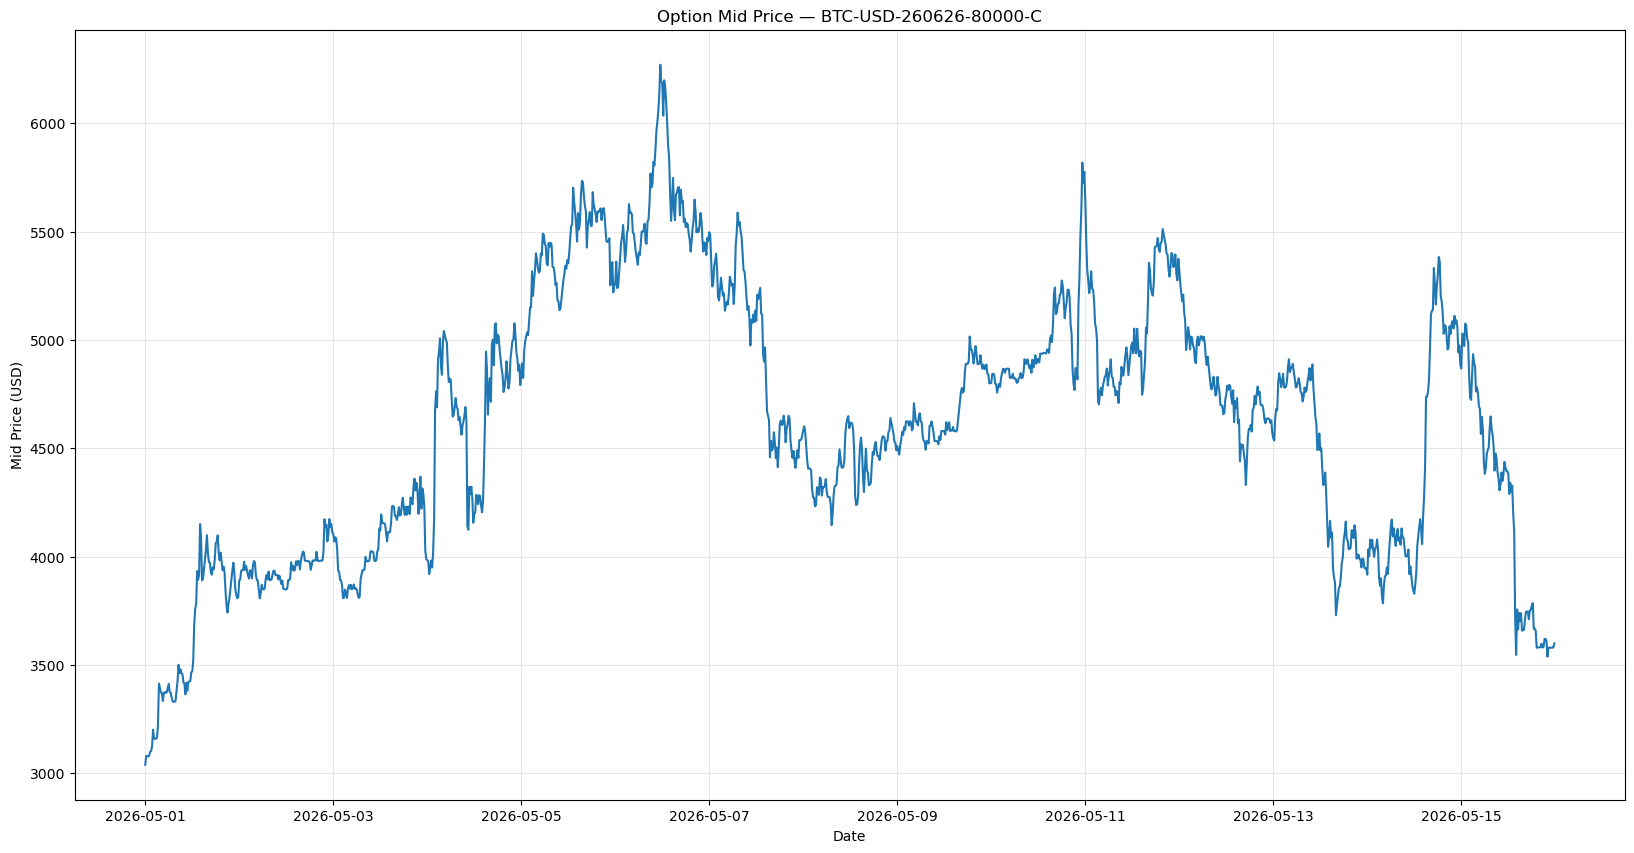

In [35]:
plt.figure(figsize=(20, 10))
plt.plot(contract_mid_snap['datetime'], contract_mid_snap['mid_usd'])
plt.title('Option Mid Price — ' + contract_name)
plt.xlabel('Date')
plt.ylabel('Mid Price (USD)')
plt.grid(alpha=0.3)
plt.show()

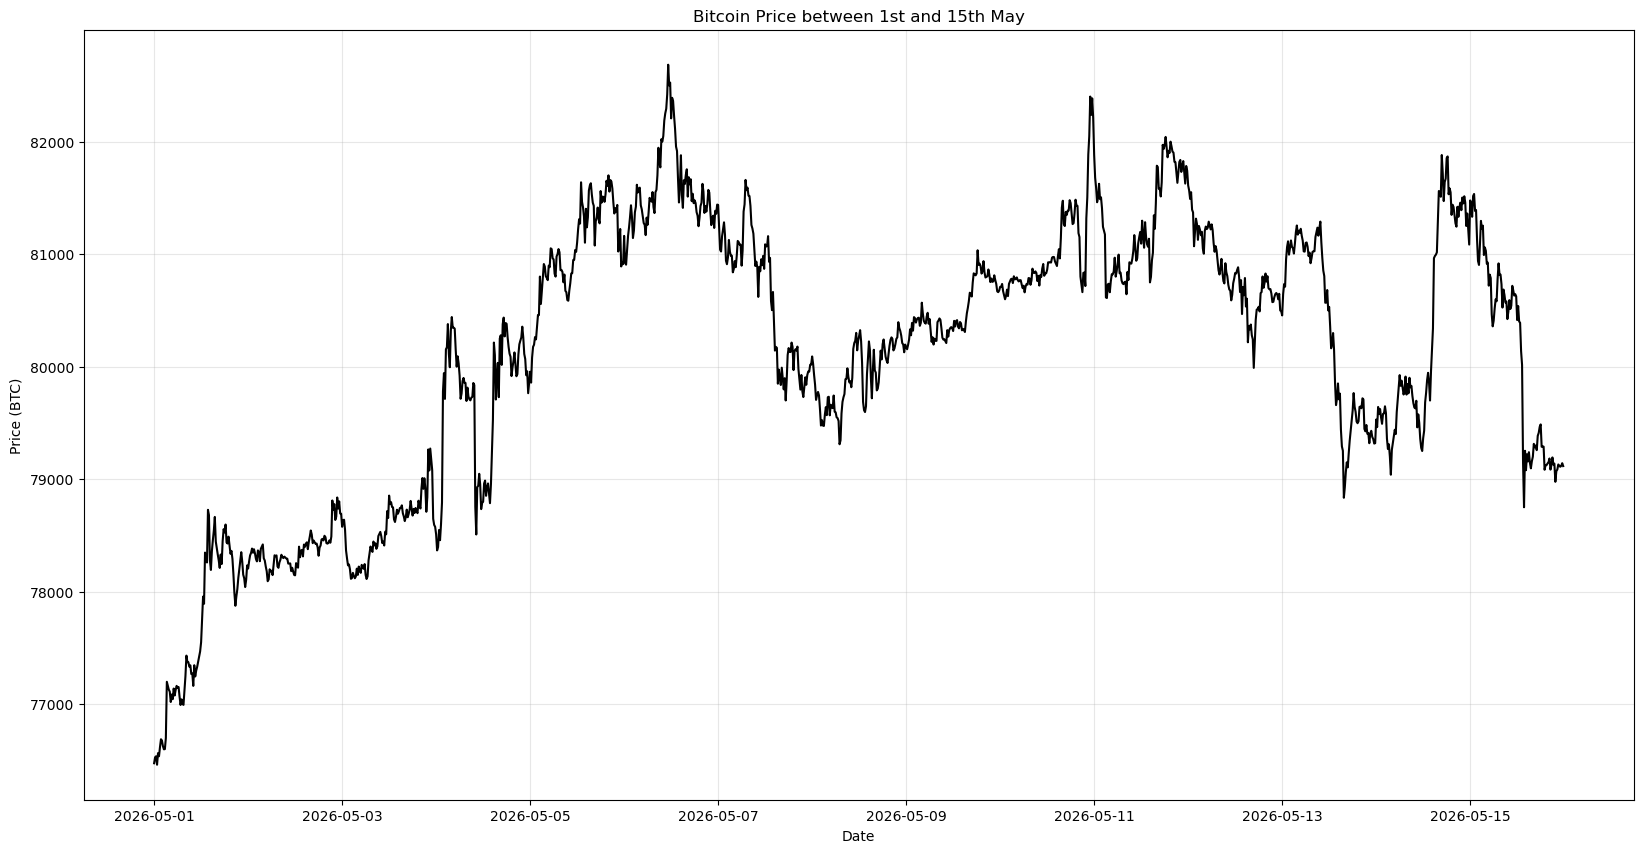

In [36]:
plt.figure(figsize=(20, 10))
plt.plot(btc_spot['ts'], btc_spot['btc_spot'], color='black')
plt.title('Bitcoin Price between 1st and 15th May')
plt.xlabel('Date')
plt.ylabel('Price (BTC)')
plt.grid(alpha=0.3)
plt.show()

In [37]:
as_df = pd.merge_asof(
    trades_contract.sort_values('datetime'),
    contract_mid_snap[['datetime', 'best_bid', 'best_ask', 'mid', 'mid_usd', 'btc_spot']].sort_values('datetime'),
    on='datetime',
    direction='backward'
).dropna()

TRAIN_END_DT = pd.Timestamp('2026-05-11')

as_df_train = as_df[as_df['datetime'] < TRAIN_END_DT].copy()
as_df_test  = as_df[as_df['datetime'] >= TRAIN_END_DT].copy()

print(f"Total trades merged: {len(as_df)}")
print(f"Train trades: {len(as_df_train)}")
print(f"Test trades:  {len(as_df_test)}")

Total trades merged: 469
Train trades: 78
Test trades:  391


In [38]:
as_df_train['price_usd']  = as_df_train['price'] * as_df_train['btc_spot']
as_df_train['best_bid_usd'] = as_df_train['best_bid'] * as_df_train['btc_spot']
as_df_train['best_ask_usd'] = as_df_train['best_ask'] * as_df_train['btc_spot']
as_df_train['mid_usd']      = as_df_train['mid'] * as_df_train['btc_spot']
as_df_train['delta_bid']    = as_df_train['mid_usd'] - as_df_train['best_bid_usd']
as_df_train['delta_ask']    = as_df_train['best_ask_usd'] - as_df_train['mid_usd']

print(f"Train trades: {len(as_df_train)}")
print(as_df_train[['datetime', 'side', 'price_usd', 'mid_usd', 'delta_bid', 'delta_ask']].head(5))

Train trades: 78
                 datetime  side  price_usd      mid_usd  delta_bid  delta_ask
0 2026-05-01 03:21:52.177  sell  3473.9955  3223.095825  19.299975  19.299975
1 2026-05-01 12:08:41.069   buy  3489.8355  3470.447525  19.387975  19.387975
2 2026-05-01 12:09:07.394   buy  3489.8355  3470.447525  19.387975  19.387975
3 2026-05-01 13:05:30.504   buy  3917.3950  3780.286175  19.586975  19.586975
4 2026-05-01 13:05:30.504   buy  3917.3950  3780.286175  19.586975  19.586975


In [39]:
import torch

bid_deltas = torch.tensor(
    as_df_train[as_df_train['side'] == 'sell']['delta_bid'].values,
    dtype=torch.float32
)
ask_deltas = torch.tensor(
    as_df_train[as_df_train['side'] == 'buy']['delta_ask'].values,
    dtype=torch.float32
)

def fit_intensity(deltas, T):
    log_A     = torch.tensor(0.0, requires_grad=True)
    log_kappa = torch.tensor(8.0, requires_grad=True)

    optimizer = torch.optim.Adam([log_A, log_kappa], lr=0.01)

    for step in range(2000):
        optimizer.zero_grad()

        A     = torch.exp(log_A)
        kappa = torch.exp(log_kappa)

        log_intensities = torch.log(A) - kappa * deltas
        integral        = A * T / kappa
        neg_ll          = -log_intensities.sum() + integral

        neg_ll.backward()
        optimizer.step()

        if step % 500 == 0:
            print(f"step {step}: A={A.item():.6f} kappa={kappa.item():.4f} nll={neg_ll.item():.2f}")

    return A.item(), kappa.item()

T = (as_df_train['datetime'].max() - as_df_train['datetime'].min()).total_seconds()

print("=== BID SIDE ===")
A_bid, kappa_bid = fit_intensity(bid_deltas, T)

print("\n=== ASK SIDE ===")
A_ask, kappa_ask = fit_intensity(ask_deltas, T)

A_sym     = (A_bid + A_ask) / 2
kappa_sym = (kappa_bid + kappa_ask) / 2

print(f"\nFitted parameters:")
print(f"Bid: A={A_bid:.6f}, kappa={kappa_bid:.4f}")
print(f"Ask: A={A_ask:.6f}, kappa={kappa_ask:.4f}")
print(f"Symmetric: A={A_sym:.6f}, kappa={kappa_sym:.4f}")

=== BID SIDE ===
step 0: A=1.000000 kappa=2980.9580 nll=2991501.50
step 500: A=0.028677 kappa=249.3051 nll=250381.64
step 1000: A=0.006023 kappa=92.3977 nll=92945.00
step 1500: A=0.002466 kappa=47.9839 nll=48397.00

=== ASK SIDE ===
step 0: A=1.000000 kappa=2980.9580 nll=3356215.75
step 500: A=0.029974 kappa=249.3028 nll=280919.06
step 1000: A=0.006829 kappa=92.3977 nll=104302.67
step 1500: A=0.002967 kappa=47.9852 nll=54329.95

Fitted parameters:
Bid: A=0.001339, kappa=28.9409
Ask: A=0.001661, kappa=28.9428
Symmetric: A=0.001500, kappa=28.9419


In [40]:
def chi2_test(deltas, A, kappa, T, n_bins=10):
    counts, bin_edges = np.histogram(deltas, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]
    
    expected = A * np.exp(-kappa * bin_centers) * bin_width * T
    
    # remove bins with expected < 5 first
    mask     = expected >= 5
    observed = counts[mask].astype(float)
    expected = expected[mask]
    
    # normalize after masking
    expected = expected * (observed.sum() / expected.sum())
    
    from scipy.stats import chisquare
    stat, p_value = chisquare(observed, expected)
    print(f"Chi2 stat: {stat:.3f}, p-value: {p_value:.4f}")
    print(f"{'Reject' if p_value < 0.05 else 'Fail to reject'} exponential assumption at 5% level")
    return stat, p_value

In [41]:
print("Bid side:")
chi2_test(
    as_df_train[as_df_train['side']=='sell']['delta_bid'].values,
    A_bid, kappa_bid, T
)

print("Ask side:")
chi2_test(
    as_df_train[as_df_train['side']=='buy']['delta_ask'].values,
    A_ask, kappa_ask, T,
    n_bins=3  # fewer bins given sparse data
)

Bid side:


/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_73706/850779010.py:14: RuntimeWarning: invalid value encountered in scalar divide
  expected = expected * (observed.sum() / expected.sum())


Chi2 stat: 0.000, p-value: nan
Fail to reject exponential assumption at 5% level
Ask side:
Chi2 stat: 0.000, p-value: nan
Fail to reject exponential assumption at 5% level


/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_73706/850779010.py:14: RuntimeWarning: invalid value encountered in scalar divide
  expected = expected * (observed.sum() / expected.sum())


(np.float64(0.0), np.float64(nan))

**Q3 A-S Simulation**

In [44]:
import numpy as np

# ============================================================
# Simulation Parameters
# ============================================================

# price path
S0      = contract_mid_snap[
    contract_mid_snap['datetime'] < pd.Timestamp('2026-05-11')
]['mid_usd'].iloc[-1]

dt      = 15 * 60        # 15-minute steps in seconds
T_sim   = 5 * 24 * 3600  # 5-day test period in seconds
n_steps = int(T_sim / dt) # 480 steps
tau     = 1               # risk horizon = 1 step

# sigma from 15-minute returns on training snapshots
train_snap = contract_mid_snap[
    contract_mid_snap['datetime'] < pd.Timestamp('2026-05-11')
].sort_values('datetime').copy()

returns = train_snap['mid_usd'].pct_change().dropna()
sigma   = returns.std() * train_snap['mid_usd'].mean()  # USD per step

# scale gamma so that gamma*sigma^2*tau ~ 2% of S0
# avoids reservation price dominating quotes
target = 0.02 * S0
gamma  = target / (sigma**2 * tau)

print(f"S0      : {S0:.2f}")
print(f"sigma   : {sigma:.4f} USD/step")
print(f"gamma   : {gamma:.6f}")
print(f"tau     : {tau}")
print(f"n_steps : {n_steps}")
print(f"A_sym   : {A_sym:.6f}")
print(f"kappa_sym: {kappa_sym:.4f}")
print(f"gamma*sigma^2*tau : {gamma * sigma**2 * tau:.4f}  ({gamma * sigma**2 * tau / S0 * 100:.2f}% of S0)")

S0      : 5775.53
sigma   : 64.5400 USD/step
gamma   : 0.027731
tau     : 1
n_steps : 480
A_sym   : 0.001500
kappa_sym: 28.9419
gamma*sigma^2*tau : 115.5105  (2.00% of S0)


In [45]:
def generate_price_path(S0, sigma, dt, n_steps):
    dW = np.random.randn(n_steps) * np.sqrt(dt)
    W  = np.cumsum(dW)
    S  = S0 + sigma * W
    S  = np.maximum(S, 1e-6)  # floor at near-zero
    return np.concatenate([[S0], S])

In [46]:
def compute_quotes(S, q, gamma, sigma, tau, kappa_bid, kappa_ask):
    r = S - q * gamma * sigma**2 * tau
    delta_bid = (1/gamma) * np.log(1 + gamma/kappa_bid) + (gamma * sigma**2 / 2) * tau
    delta_ask = (1/gamma) * np.log(1 + gamma/kappa_ask) + (gamma * sigma**2 / 2) * tau
    bid       = r - delta_bid
    ask       = r + delta_ask
    return r, bid, ask, delta_bid, delta_ask

In [47]:
def simulate_fills(bid, ask, S, A_bid, kappa_bid, A_ask, kappa_ask, dt):
    
    lam_bid = A_bid * np.exp(-kappa_bid * max(S - bid, 0))
    lam_ask = A_ask * np.exp(-kappa_ask * max(ask - S, 0))
    
    # exact Poisson probability: P(at least one fill) = 1 - exp(-lambda * dt)
    p_bid = 1 - np.exp(-lam_bid * dt)
    p_ask = 1 - np.exp(-lam_ask * dt)
    
    bid_filled = np.random.random() < p_bid
    ask_filled = np.random.random() < p_ask
    
    return bid_filled, ask_filled

In [48]:
def simulate_path(price_path, sigma, gamma, tau, A_bid, kappa_bid, A_ask, kappa_ask, dt):
    S_path   = price_path
    n_steps = len(S_path) - 1
    
    q, X     = 0, 0.0
    q_path        = [0]
    cash_pnl_path = [0.0]   # spread income only
    mtm_path      = [0.0]   # total mark-to-market
    
    for t in range(n_steps):
        S = S_path[t]
        
        r, bid, ask, db, da = compute_quotes(S, q, gamma, sigma, tau, kappa_bid, kappa_ask)
        bid_filled, ask_filled = simulate_fills(bid, ask, S, A_bid, kappa_bid, A_ask, kappa_ask, dt)
        
        if bid_filled:
            q += 1
            X -= bid
        if ask_filled:
            q -= 1
            X += ask
        
        S_next = S_path[t + 1] if t + 1 < len(S_path) else S
        
        q_path.append(q)
        cash_pnl_path.append(X)
        mtm_path.append(X + q * S_next)
    
    return np.array(q_path), np.array(cash_pnl_path), np.array(mtm_path)

In [49]:
def simulate_path_symmetric(price_path, sigma, gamma, tau, A_sym, kappa_sym, dt):
    S_path      = price_path
    n_steps = len(S_path) - 1
    
    q, X        = 0, 0.0
    q_path      = [0]
    cash_pnl_path = [0.0]
    mtm_path    = [0.0]
    
    half_spread = (1/gamma) * np.log(1 + gamma/kappa_sym)
    
    for t in range(n_steps):
        S   = S_path[t]
        bid = max(S - half_spread, 1e-6)
        ask = S + half_spread
        
        bid_filled, ask_filled = simulate_fills(
            bid, ask, S, A_sym, kappa_sym, A_sym, kappa_sym, dt
        )
        if bid_filled:
            q += 1;  X -= bid
        if ask_filled:
            q -= 1;  X += ask
        
        S_next = S_path[t+1] if t+1 < len(S_path) else S
        q_path.append(q)
        cash_pnl_path.append(X)
        mtm_path.append(X + q * S_next)
    
    return np.array(q_path), np.array(cash_pnl_path), np.array(mtm_path)

# run symmetric

In [51]:
S_path = generate_price_path(S0, sigma, dt, n_steps)

q_path, cash_pnl_path, mtm_path = simulate_path(
    S_path, sigma, gamma, tau,
    A_sym, kappa_sym,
    A_sym, kappa_sym,
    dt
)

q_path_sym, cash_sym, mtm_sym = simulate_path_symmetric(
    S_path, sigma, gamma, tau, A_sym, kappa_sym, dt
)

In [52]:
print(f"kappa_sym : {kappa_sym:.6f}")
print(f"A_sym     : {A_sym:.6f}")
print(f"tau       : {tau}")

kappa_sym : 28.941862
A_sym     : 0.001500
tau       : 1


/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_73706/3222201527.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


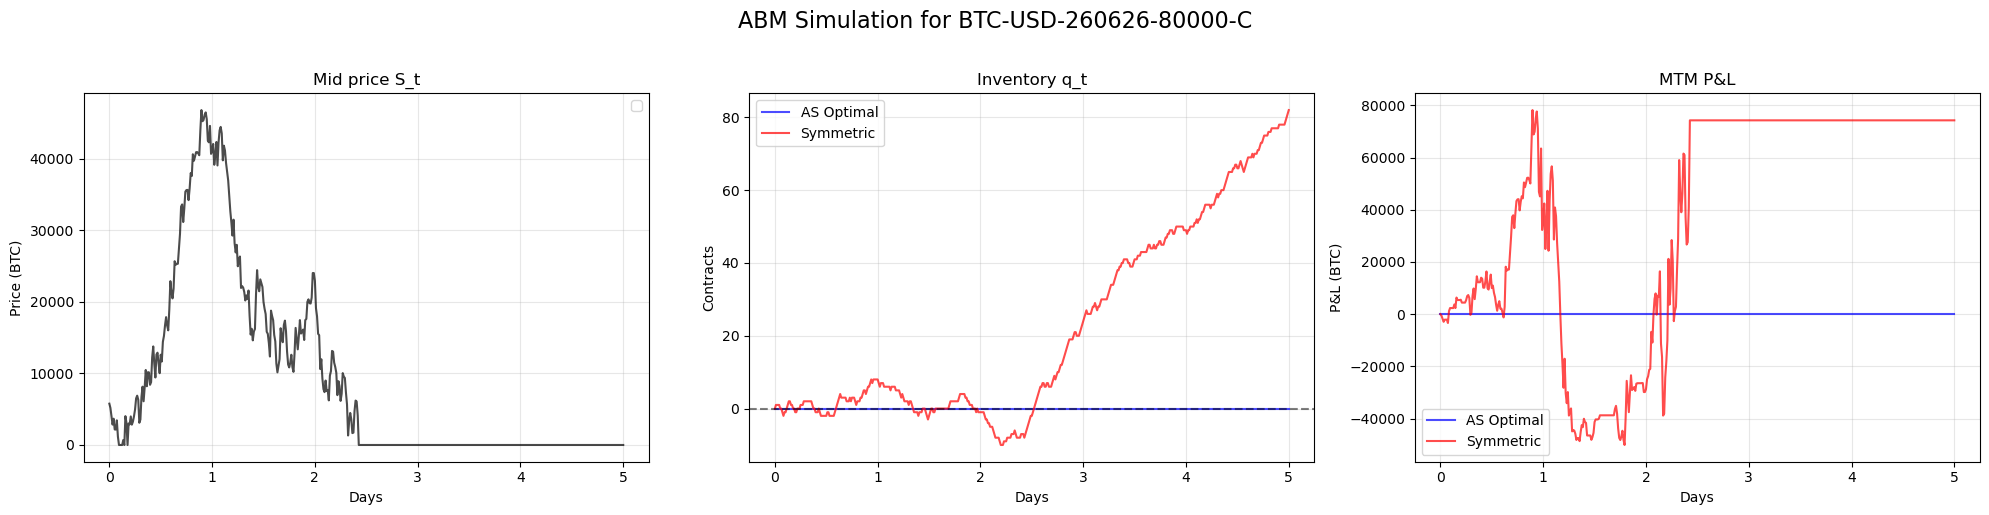

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

t = np.arange(len(q_path)) / (24 * 3600 / dt)

plt.suptitle('ABM Simulation for ' + contract_name, fontsize=16, y=1.02)

axes[0].plot(t, S_path[:len(q_path)], alpha=0.7, color='black', )

axes[1].plot(t, q_path,     alpha=0.7, label='AS Optimal', color='blue')
axes[1].plot(t, q_path_sym, alpha=0.7, label='Symmetric',  color='red')

axes[2].plot(t, mtm_path, alpha=0.7, label='AS Optimal', color='blue')
axes[2].plot(t, mtm_sym,  alpha=0.7, label='Symmetric',  color='red')

axes[0].set_title('Mid price S_t');    axes[0].set_ylabel('Price (BTC)')
axes[1].set_title('Inventory q_t');    axes[1].set_ylabel('Contracts')
axes[2].set_title('MTM P&L');          axes[2].set_ylabel('P&L (BTC)')

axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Days')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# ── P&L Metrics ───────────────────────────────────────────────────────────────
print("=== P&L Metrics ===")
print(f"AS  final cash P&L : {cash_pnl_path[-1]:.4f} USD")
print(f"Sym final cash P&L : {cash_sym[-1]:.4f} USD")
print(f"AS  final MTM P&L  : {mtm_path[-1]:.4f} USD")
print(f"Sym final MTM P&L  : {mtm_sym[-1]:.4f} USD")
print()

# ── Inventory Metrics ─────────────────────────────────────────────────────────
print("=== Inventory Metrics ===")
print(f"AS  mean inventory : {np.mean(q_path):.4f}")
print(f"AS  std inventory  : {np.std(q_path):.4f}")
print(f"AS  max long       : {np.max(q_path):.0f}")
print(f"AS  max short      : {np.min(q_path):.0f}")
print()
print(f"Sym mean inventory : {np.mean(q_path_sym):.4f}")
print(f"Sym std inventory  : {np.std(q_path_sym):.4f}")
print(f"Sym max long       : {np.max(q_path_sym):.0f}")
print(f"Sym max short      : {np.min(q_path_sym):.0f}")
print()
print(f"Inventory std ratio (Sym/AS): {np.std(q_path_sym)/max(np.std(q_path),1e-10):.2f}x")
print()

# ── Sharpe Ratio ──────────────────────────────────────────────────────────────
daily_steps = int(86400 / dt)
n_days      = len(mtm_path) // daily_steps

as_daily  = [mtm_path[(i+1)*daily_steps] - mtm_path[i*daily_steps] for i in range(n_days)]
sym_daily = [mtm_sym[(i+1)*daily_steps]  - mtm_sym[i*daily_steps]  for i in range(n_days)]

as_sharpe  = np.mean(as_daily)  / (np.std(as_daily)  + 1e-10)
sym_sharpe = np.mean(sym_daily) / (np.std(sym_daily) + 1e-10)

print("=== Sharpe Ratio (daily MTM P&L) ===")
print(f"AS  Sharpe : {as_sharpe:.4f}")
print(f"Sym Sharpe : {sym_sharpe:.4f}")

=== P&L Metrics ===
AS  final cash P&L : 0.0000 USD
Sym final cash P&L : 74302.1747 USD
AS  final MTM P&L  : 0.0000 USD
Sym final MTM P&L  : 74302.1747 USD

=== Inventory Metrics ===
AS  mean inventory : 0.0000
AS  std inventory  : 0.0000
AS  max long       : 0
AS  max short      : 0

Sym mean inventory : 22.1476
Sym std inventory  : 26.9975
Sym max long       : 82
Sym max short      : -10

Inventory std ratio (Sym/AS): 269975173937.77x

=== Sharpe Ratio (daily MTM P&L) ===
AS  Sharpe : 0.0000
Sym Sharpe : 0.2707


**BackTest**

In [56]:
def run_backtest(df, quote_fn, gamma, sigma, kappa, tau):
    cash, inventory = 0.0, 0.0
    records = []

    for _, row in df.iterrows():
        mid         = row['mid_usd']
        trade_price = row['price'] * row['btc_spot']
        trade_side  = row['side']

        bid, ask = quote_fn(mid, inventory, gamma, sigma, kappa, tau)

        if trade_side == 'buy' and trade_price >= ask:
            inventory -= 1;  cash += ask
        elif trade_side == 'sell' and trade_price <= bid:
            inventory += 1;  cash -= bid

        records.append({
            'datetime' : row['datetime'],
            'mid'      : mid,
            'bid'      : bid,
            'ask'      : ask,
            'inventory': inventory,
            'cash'     : cash,
            'pnl'      : cash + inventory * mid
        })

    return pd.DataFrame(records)

opt_result  = run_backtest(as_df_test, as_quote_fn,        gamma, sigma, kappa_sym, tau)
base_result = run_backtest(as_df_test, symmetric_quote_fn, gamma, sigma, kappa_sym, tau)

print(f"AS optimal  — final PnL: ${opt_result['pnl'].iloc[-1]:.2f},  fills: {(opt_result['inventory'].diff() != 0).sum()}")
print(f"AS symmetric — final PnL: ${base_result['pnl'].iloc[-1]:.2f}, fills: {(base_result['inventory'].diff() != 0).sum()}")

AS optimal  — final PnL: $36962.98,  fills: 92
AS symmetric — final PnL: $32753.45, fills: 256


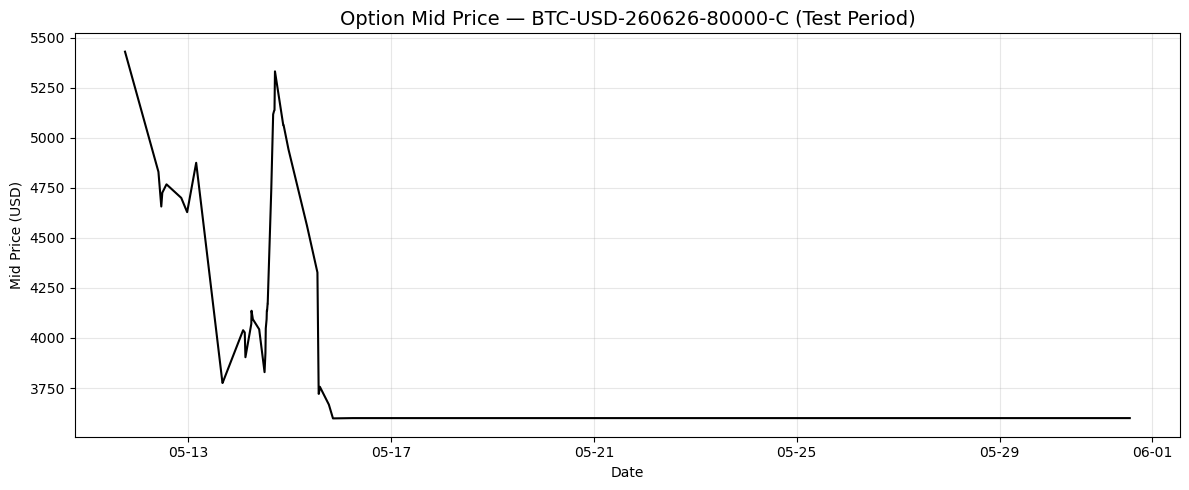

In [57]:
import matplotlib.dates as mdates

# ============================================================
# AS Viz 1 — Mid Price
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(opt_result['datetime'], opt_result['mid'],
        color='black', linewidth=1.5)
ax.set_title(f'Option Mid Price — {contract_name} (Test Period)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Mid Price (USD)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

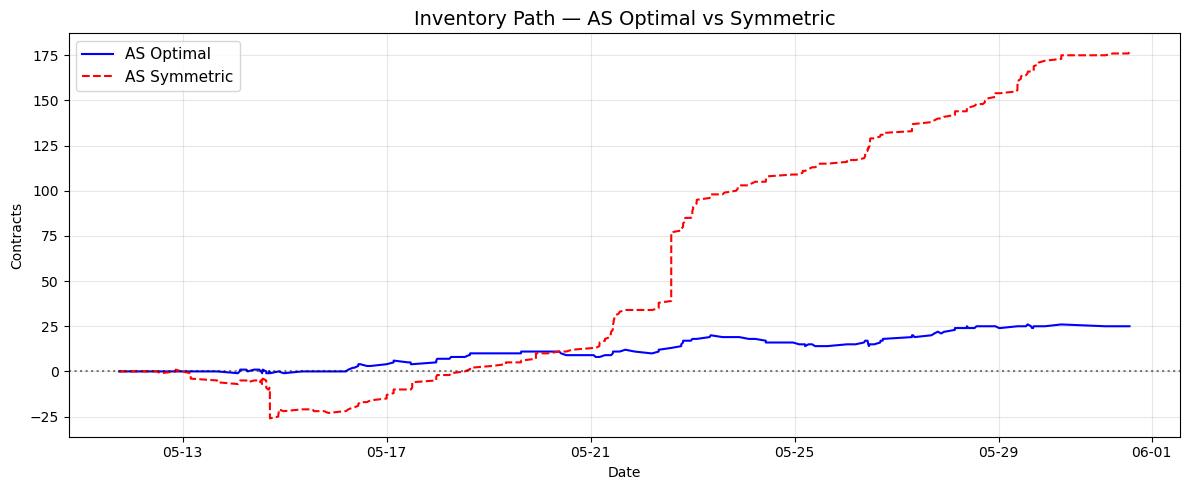

In [58]:
# ============================================================
# AS Viz 2 — Inventory Path
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(opt_result['datetime'], opt_result['inventory'],
        color='blue', linewidth=1.5, label='AS Optimal')
ax.plot(base_result['datetime'], base_result['inventory'],
        color='red', linewidth=1.5, linestyle='--', label='AS Symmetric')
ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.set_title('Inventory Path — AS Optimal vs Symmetric', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Contracts')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

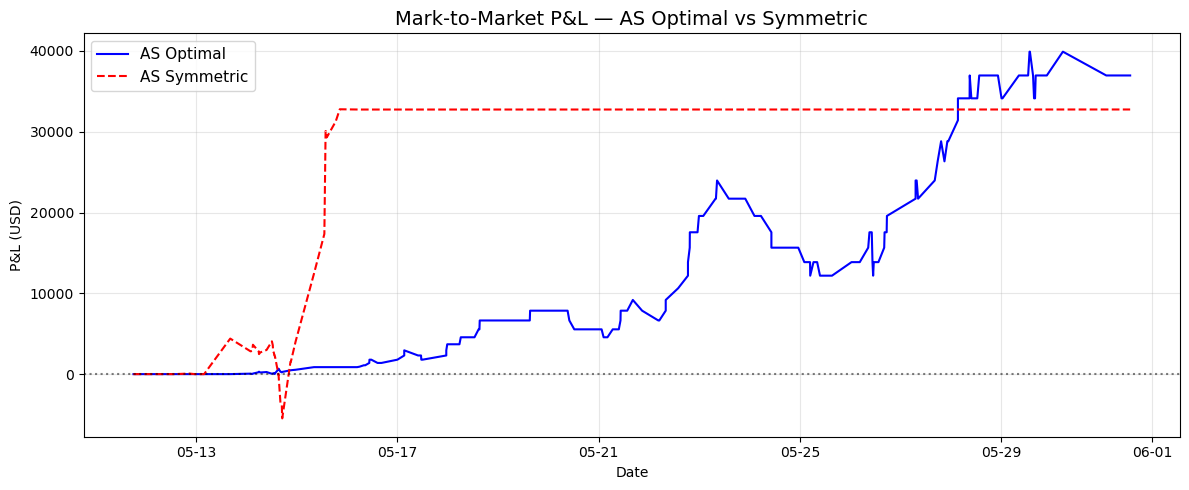

In [59]:
# ============================================================
# AS Viz 3 — P&L Path
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(opt_result['datetime'], opt_result['pnl'],
        color='blue', linewidth=1.5, label='AS Optimal')
ax.plot(base_result['datetime'], base_result['pnl'],
        color='red', linewidth=1.5, linestyle='--', label='AS Symmetric')
ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.set_title('Mark-to-Market P&L — AS Optimal vs Symmetric', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('P&L (USD)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# AS Metrics
# ============================================================

def as_metrics(result, label):
    fills     = (result['inventory'].diff() != 0).sum()
    final_pnl = result['pnl'].iloc[-1]
    max_inv   = result['inventory'].abs().max()
    mean_inv  = result['inventory'].abs().mean()

    running_max = result['pnl'].cummax()
    max_dd      = (running_max - result['pnl']).max()

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Final PnL:        ${final_pnl:>10.2f}")
    print(f"  Max drawdown:     ${max_dd:>10.2f}")
    print(f"  Total fills:      {fills:>10.0f}")
    print(f"  Mean |inventory|: {mean_inv:>10.4f}")
    print(f"  Max |inventory|:  {max_inv:>10.0f}")

as_metrics(opt_result,  'AS Optimal')
as_metrics(base_result, 'AS Symmetric')


  AS Optimal
  Final PnL:        $  36962.98
  Max drawdown:     $  11781.87
  Total fills:              92
  Mean |inventory|:    12.2506
  Max |inventory|:          26

  AS Symmetric
  Final PnL:        $  32753.45
  Max drawdown:     $   9875.64
  Total fills:             256
  Mean |inventory|:    69.0000
  Max |inventory|:         177


In [64]:
import pandas as pd
import numpy as np

# load El Aoud quotes
el_aoud_quotes_df = pd.read_parquet('../../RandomData/el_aoud_quotes.parquet')

trades_test_ed = as_df_test.rename(columns={'price': 'price_btc'}).copy()
print(f"Test trades: {len(trades_test_ed)}")

# compare quote widths on actual test trades
print("Trade prices vs El Aoud and AS quotes:\n")
print(f"{'Date':<20} {'Side':<5} {'Price':>8} | {'EA Bid':>8} {'EA Ask':>8} {'EA Hit':<6} | {'AS Bid':>8} {'AS Ask':>8} {'AS Hit':<6}")
print("-" * 90)

for _, trade in trades_test_ed.sort_values('datetime').iterrows():
    trade_dt    = trade['datetime']
    trade_price = trade['price_btc'] * trade['btc_spot']
    trade_side  = trade['side']

    # El Aoud quotes — nearest snapshot at or before trade
    ea_snap = el_aoud_quotes_df[el_aoud_quotes_df['datetime'] <= trade_dt]
    if ea_snap.empty:
        continue
    ea_snap  = ea_snap.iloc[-1]
    ea_bid   = ea_snap['ea_bid']
    ea_ask   = ea_snap['ea_ask']

    # AS quotes — nearest snapshot at or before trade
    as_snap = contract_mid_snap[contract_mid_snap['datetime'] <= trade_dt]
    if as_snap.empty:
        continue
    as_snap     = as_snap.iloc[-1]
    mid         = as_snap['mid_usd']
    half_spread = (1/gamma) * np.log(1 + gamma/kappa_sym)
    as_bid      = mid - half_spread
    as_ask      = mid + half_spread

    ea_hit = ((trade_side == 'buy'  and trade_price >= ea_ask) or
              (trade_side == 'sell' and trade_price <= ea_bid))
    as_hit = ((trade_side == 'buy'  and trade_price >= as_ask) or
              (trade_side == 'sell' and trade_price <= as_bid))

    print(f"{str(trade_dt)[:19]:<20} {trade_side:<5} {trade_price:>8.0f} | "
          f"{ea_bid:>8.0f} {ea_ask:>8.0f} {'HIT' if ea_hit else '---':<6} | "
          f"{as_bid:>8.0f} {as_ask:>8.0f} {'HIT' if as_hit else '---':<6}")

Test trades: 391
Trade prices vs El Aoud and AS quotes:

Date                 Side     Price |   EA Bid   EA Ask EA Hit |   AS Bid   AS Ask AS Hit
------------------------------------------------------------------------------------------
2026-05-11 18:09:51  sell      5492 |     5046     5476 ---    |     5430     5431 ---   
2026-05-12 09:58:33  buy       4810 |     4314     4857 ---    |     4830     4830 ---   
2026-05-12 11:19:22  buy       4596 |     4242     4688 ---    |     4657     4657 ---   
2026-05-12 11:19:22  buy       4596 |     4242     4688 ---    |     4657     4657 ---   
2026-05-12 11:19:22  buy       4596 |     4242     4688 ---    |     4657     4657 ---   
2026-05-12 11:48:16  buy       4726 |     4334     4759 ---    |     4726     4726 ---   
2026-05-12 11:48:16  buy       4726 |     4334     4759 ---    |     4726     4726 ---   
2026-05-12 11:48:16  buy       4726 |     4334     4759 ---    |     4726     4726 ---   
2026-05-12 11:48:16  buy       4726 |     

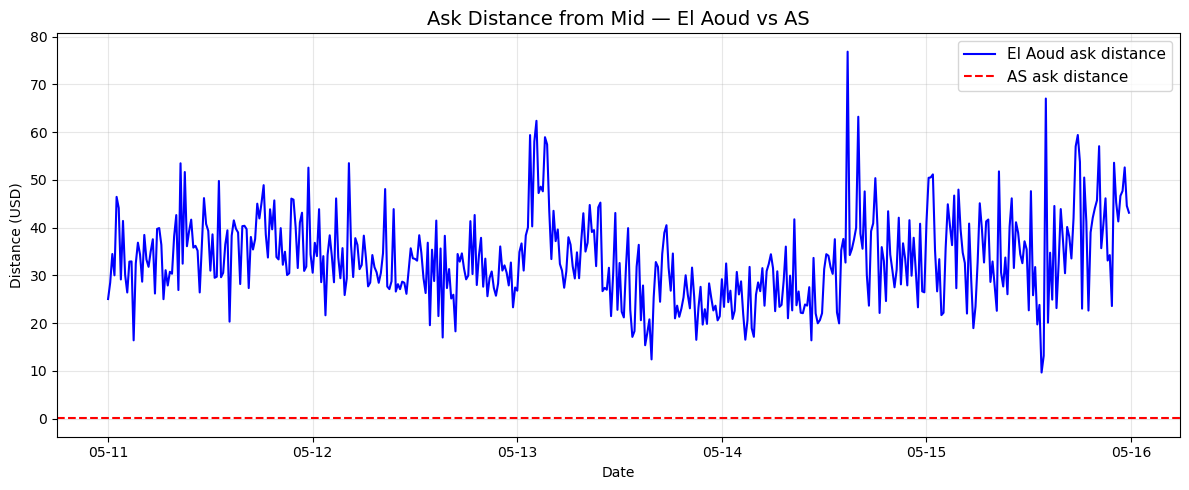

In [66]:
# ============================================================
# Quote Width Comparison — El Aoud vs AS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# build quote comparison dataframe aligned on timestamps
el_aoud_quotes_df['as_half_spread'] = (1/gamma) * np.log(1 + gamma/kappa_sym)
el_aoud_quotes_df['ea_spread']      = el_aoud_quotes_df['ea_dp'] + el_aoud_quotes_df['ea_dm']
el_aoud_quotes_df['as_spread']      = 2 * el_aoud_quotes_df['as_half_spread']

# Plot 1 — Ask distance from mid
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(el_aoud_quotes_df['datetime'], el_aoud_quotes_df['ea_dp'],
        color='blue', linewidth=1.5, label='El Aoud ask distance')
ax.axhline(el_aoud_quotes_df['as_half_spread'].iloc[0],
           color='red', linewidth=1.5, linestyle='--', label='AS ask distance')
ax.set_title('Ask Distance from Mid — El Aoud vs AS', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Distance (USD)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

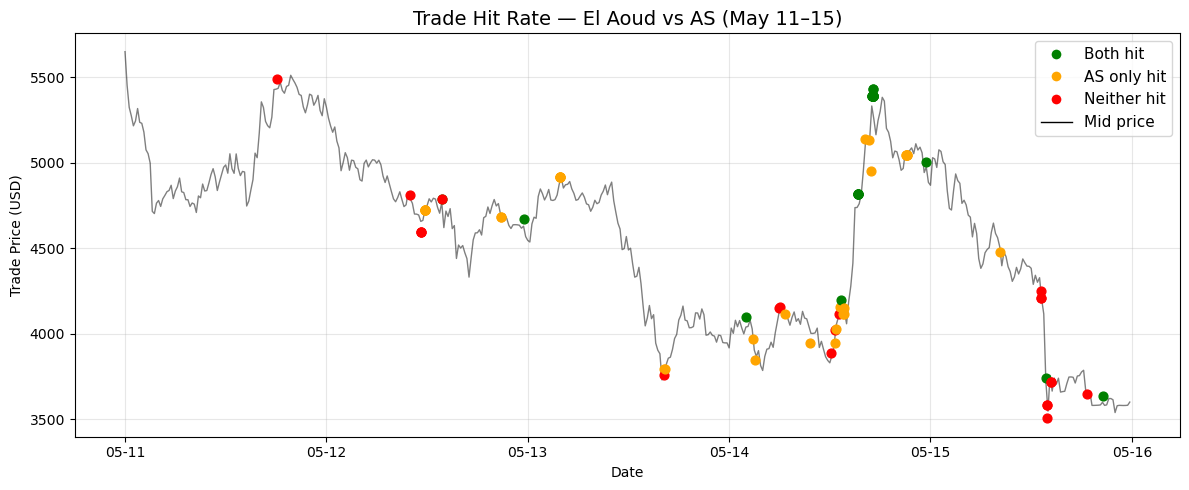

In [77]:
# ============================================================
# Plot 2 — Trade Hit Rate Scatter (May 11-15 only)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

# filter to test period only
trades_plot = trades_test_ed[
    trades_test_ed['datetime'] <= pd.Timestamp('2026-05-15 23:59:59')
].sort_values('datetime')

mid_plot = contract_mid_snap[
    contract_mid_snap['datetime'].between(
        pd.Timestamp('2026-05-11'),
        pd.Timestamp('2026-05-15 23:59:59')
    )
].sort_values('datetime')

half_spread = float(el_aoud_quotes_df['as_half_spread'].iloc[0])

for _, trade in trades_plot.iterrows():
    trade_dt    = trade['datetime']
    trade_price = trade['price_btc'] * trade['btc_spot']
    trade_side  = trade['side']

    ea_snap = el_aoud_quotes_df[el_aoud_quotes_df['datetime'] <= trade_dt]
    if ea_snap.empty:
        continue
    ea_snap = ea_snap.iloc[-1]

    as_snap = mid_plot[mid_plot['datetime'] <= trade_dt]
    if as_snap.empty:
        continue
    as_snap = as_snap.iloc[-1]

    mid    = float(as_snap['mid_usd'])
    ea_ask = float(ea_snap['ea_ask'])
    ea_bid = float(ea_snap['ea_bid'])

    ea_hit = ((trade_side == 'buy'  and trade_price >= ea_ask) or
              (trade_side == 'sell' and trade_price <= ea_bid))
    as_hit = ((trade_side == 'buy'  and trade_price >= mid - half_spread) or
              (trade_side == 'sell' and trade_price <= mid + half_spread))

    color = 'green' if ea_hit else ('orange' if as_hit else 'red')
    ax.scatter(trade_dt, trade_price, color=color, s=40, zorder=3)

# mid price line
ax.plot(mid_plot['datetime'], mid_plot['mid_usd'],
        color='black', linewidth=1.0, alpha=0.5, label='Mid price')

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=8, label='Both hit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
           markersize=8, label='AS only hit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=8, label='Neither hit'),
    Line2D([0], [0], color='black', linewidth=1.0, label='Mid price'),
]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_title('Trade Hit Rate — El Aoud vs AS (May 11–15)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Trade Price (USD)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

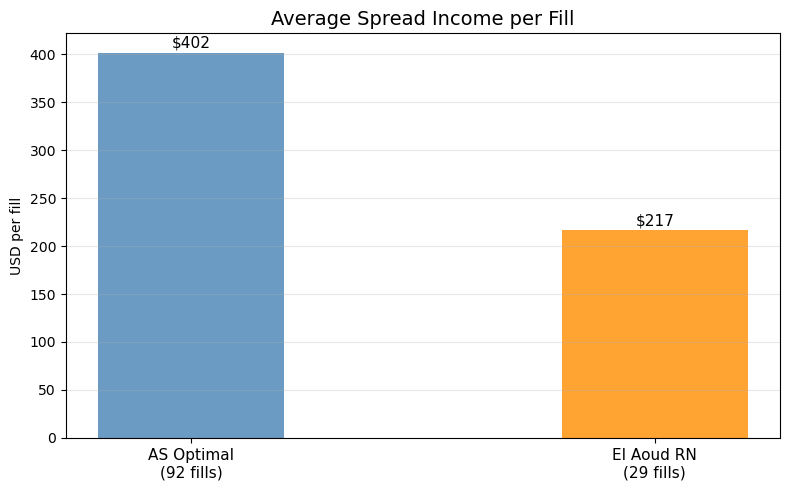

In [68]:
# Plot 3 — Spread income per fill comparison
fig, ax = plt.subplots(figsize=(8, 5))

strategies   = ['AS Optimal\n(92 fills)', 'El Aoud RN\n(29 fills)']
per_fill     = [opt_result['pnl'].iloc[-1] / 92, 6291 / 29]
total_pnl    = [opt_result['pnl'].iloc[-1], 6291]

x = np.arange(len(strategies))
bars = ax.bar(x, per_fill, color=['steelblue', 'darkorange'], alpha=0.8, width=0.4)

ax.set_title('Average Spread Income per Fill', fontsize=14)
ax.set_ylabel('USD per fill')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, per_fill):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'${val:.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()